## MSD from LAMMPS fix

Let's use this to find the terminal relaxation time.

Each timestep is 0.005 $\tau$ and each snapshot is 10000 apart from each other.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = "data/msd/prodmsd_chainlength_30_N_beads_24000_gaussA_20_r0_0.35_gaussB_10_seed_12345.dat"

times = []
msd = []
msd_calculated = []
msd_std = []
counts = []

# columns are chunk_id, dx^2, dy^2, dz^2, RMSD^2
with open(filename, 'r') as f:
    while True:
        line = f.readline()
        if not line:
            break
        if line.startswith("#"):
            # print("skipping header line")
            continue
        # print("processing line:", line)
        current_timestep, num_entries = line.strip().split() # get the timestep from the next line after the header
        # print(f"Current timestep: {current_timestep}, Number of entries: {num_entries}")
        dx_values = np.zeros(int(num_entries))
        dy_values = np.zeros(int(num_entries))
        dz_values = np.zeros(int(num_entries))
        RMSD_values = np.zeros(int(num_entries))
        for i in range(int(num_entries)):
            _, dx_values[i], dy_values[i], dz_values[i], RMSD_values[i] = next(f).strip().split() # read the RMSD value from the 5th column of each line
        rms_calculated = np.mean(dx_values + dy_values + dz_values)

        # average over all chains for this timestep
        msd_calculated.append(np.mean(rms_calculated))
        times.append(current_timestep)
        msd.append(np.mean(RMSD_values))
        msd_std.append(np.std(RMSD_values))
        counts.append(int(num_entries))

In [4]:
times = np.array(times, dtype=float)
times = times - times[0] # shift time to start from 0
times = times * 0.005
msd = np.array(msd, dtype=float)
msd_calculated = np.array(msd_calculated, dtype=float)
msd_std = np.array(msd_std, dtype=float)
counts = np.array(counts, dtype=int)
# print(times)

In [5]:
msd_file = "data/msd/msd.csv"
df = pd.read_csv(msd_file, header=None, names=["time", "msd"])


13703 13703


/tmp/ipykernel_65430/688646681.py:3: RuntimeWarning: invalid value encountered in divide
  plt.loglog(times, msd/np.sqrt(times), label="MSD from LAMMPS")


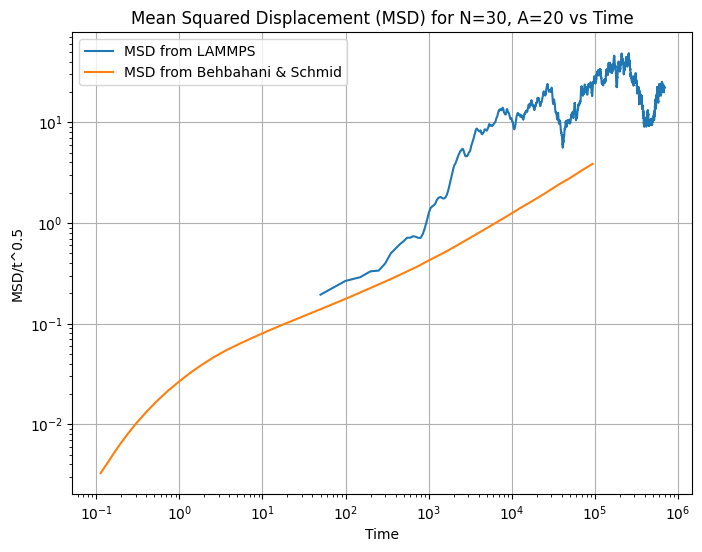

In [6]:
print(len(times), len(msd))
figure = plt.figure(figsize=(8, 6))
plt.loglog(times, msd/np.sqrt(times), label="MSD from LAMMPS")
plt.loglog(df["time"], df["msd"], label="MSD from Behbahani & Schmid")
# plt.plot(times, msd_calculated, label="MSD calculated from dx, dy, dz")
plt.title("Mean Squared Displacement (MSD) for N=30, A=20 vs Time")
plt.xlabel("Time")
plt.ylabel("MSD/t^0.5")
plt.grid()
plt.legend()
plt.show()

## Calculation based on Behbahani & Schmid data

The data from Figure 2d) is

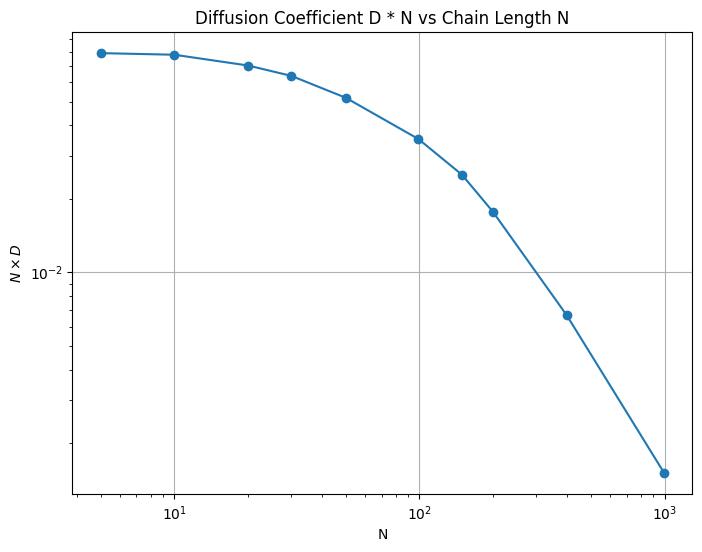

In [7]:
file = "data/msd/NxD.csv"

df = pd.read_csv(file, header=None, names=["N", "D*N"])
df["N"] = df["N"].round().astype(int)  # round N to nearest integer
plt.figure(figsize=(8, 6))
plt.loglog(df["N"], df["D*N"], marker='o')
plt.title("Diffusion Coefficient D * N vs Chain Length N")
plt.xlabel(r"N")
plt.ylabel(r"$N \times D$")
plt.grid()
plt.show()

In [8]:
DN_30 = df["D*N"][df["N"] == 30].values[0]
print(f"D*N for N=30: {DN_30}")

D*N for N=30: 0.06364


The relation for Rouse time we can use is

$$
D N = \frac{kT}\zeta
$$
$$
\tau_R = \frac{\zeta b^2 N^2}{ 3 \pi^2 kT}
$$
$$
\tau_R = \frac{b^2 N^2}{ 3 \pi^2 DN}
$$

In [9]:
b = 0.97
N = 30
DN = DN_30

tau_rouse = b**2 * N**2 / (3 * np.pi**2 * DN)
print(f"Rouse relaxation time for N=30: {tau_rouse:.2f} time units")

Rouse relaxation time for N=30: 449.40 time units


In [10]:
timesteps_rouse = tau_rouse/0.005
print(f"Rouse relaxation time in timesteps: {timesteps_rouse:.0f} timesteps")

Rouse relaxation time in timesteps: 89880 timesteps


## Average bond lifetime + bonding rate from averaging lifetime

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_60_r0_0.25_gaussB_10_seed_12345.bin.txt"

N_patches = 4000
frame = 11

with open(f, "r") as file:
    for i in range((frame - 1) * (9 + N_patches) + 1):
        line = file.readline()
    # for i in range(9):
    print("Timestep:", file.readline())

df = pd.read_csv(f, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)
print(df[df["patch_coord"] == 2])
print(df[df["patch_cluster"] == 8575])

Timestep: 100

Empty DataFrame
Columns: [id, mol, x, y, z, patch_coord, patch_cluster]
Index: []
        id  mol        x        y        z  patch_coord  patch_cluster
1489  8575  245  28.2518  3.62236  30.2707            0           8575


3891
3891
0
109


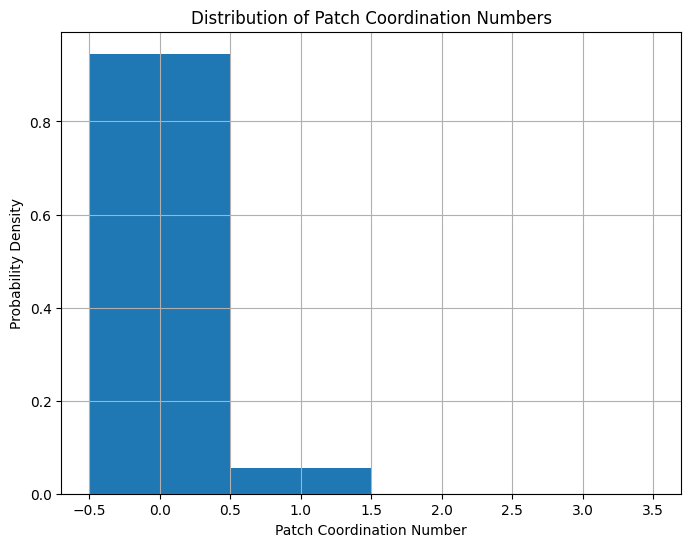

In [114]:
patch_cluster_list = np.unique(df["patch_cluster"].values)
print(len(patch_cluster_list))
cluster_size_list = np.zeros(len(patch_cluster_list))
print(len(cluster_size_list))


for i, patch_cluster in enumerate(patch_cluster_list):
    this_patch = df[df["patch_cluster"] == patch_cluster]
    # print("Patch id:", patch_cluster)
    # print(this_patch)
    cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values)
    # print(f"Cluster {patch_cluster} has size {cluster_size_list[i]}")


# percentage of bonds with 3 patches
num_3_patch_bonds = np.sum(cluster_size_list == 2)
print(num_3_patch_bonds)
total_bonds = np.sum(cluster_size_list == 2) + np.sum(cluster_size_list == 1) # only consider bonds with at least 1 patch
print(total_bonds)
# percentage_3_patch_bonds = (num_3_patch_bonds / total_bonds) * 100
# print(f"Percentage of bonds with 3 patches: {percentage_3_patch_bonds:.2f}%")

# histogram of patch_coord
plt.figure(figsize=(8, 6))
plt.hist(df["patch_coord"], bins=np.arange(-0.5, 4.5, 1), density=True)
plt.title("Distribution of Patch Coordination Numbers")
plt.xlabel("Patch Coordination Number")
plt.ylabel("Probability Density")
plt.grid()
plt.show()  

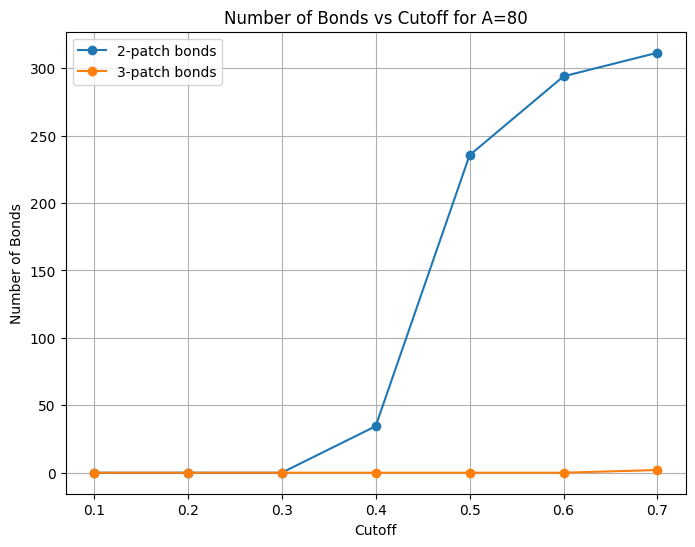

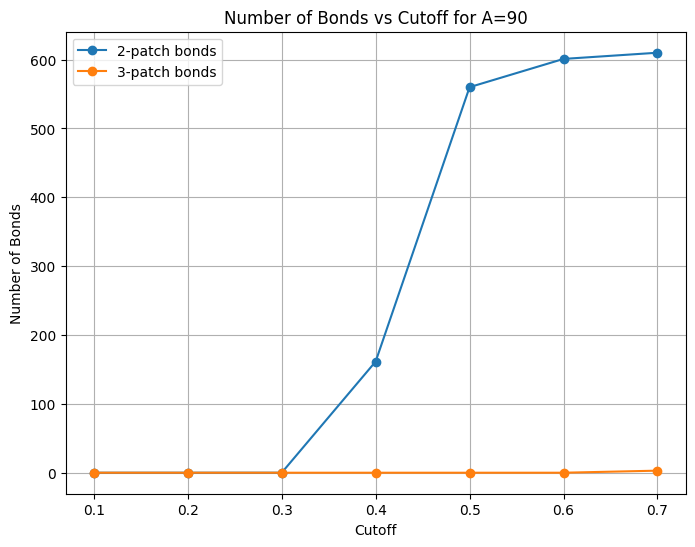

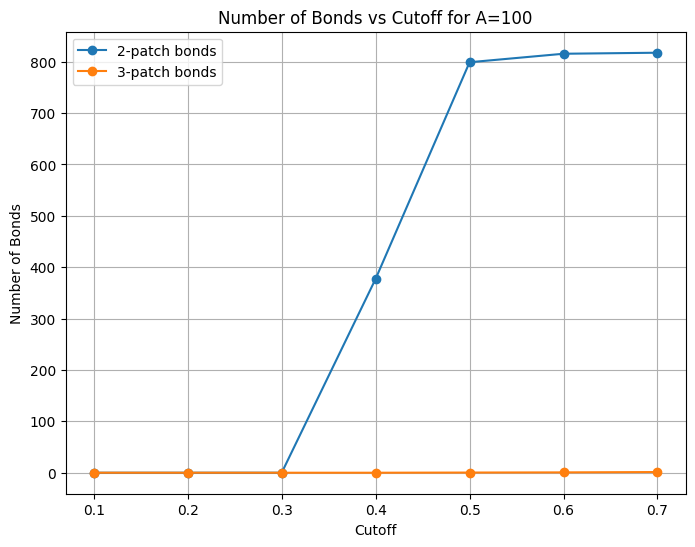

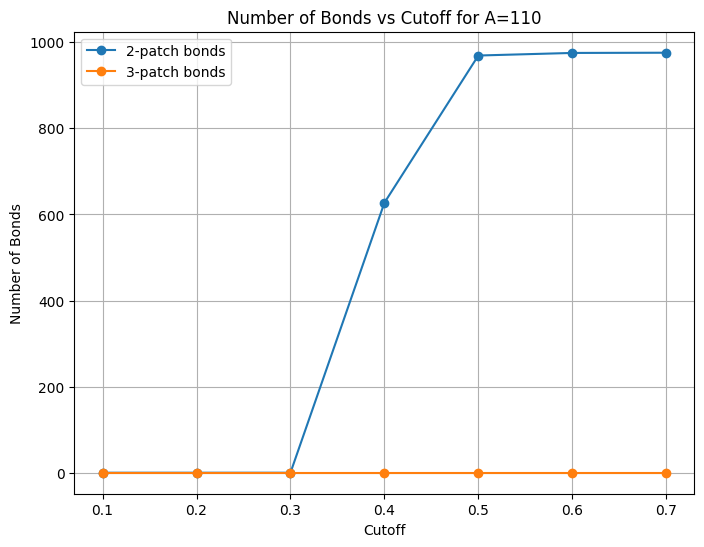

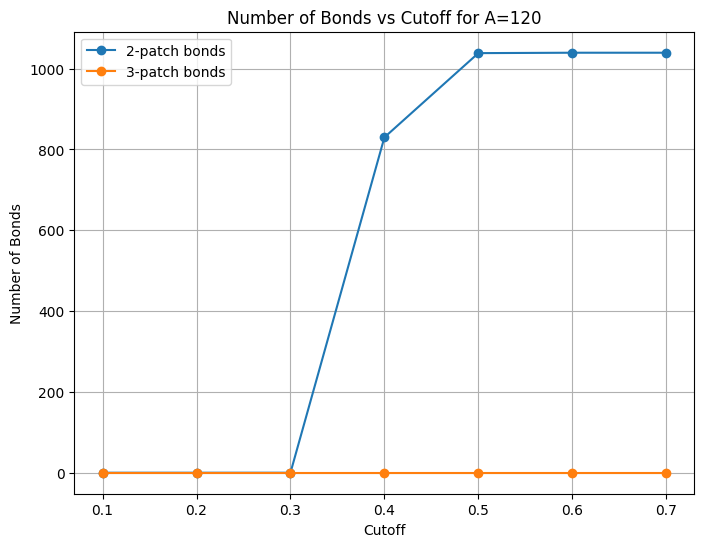

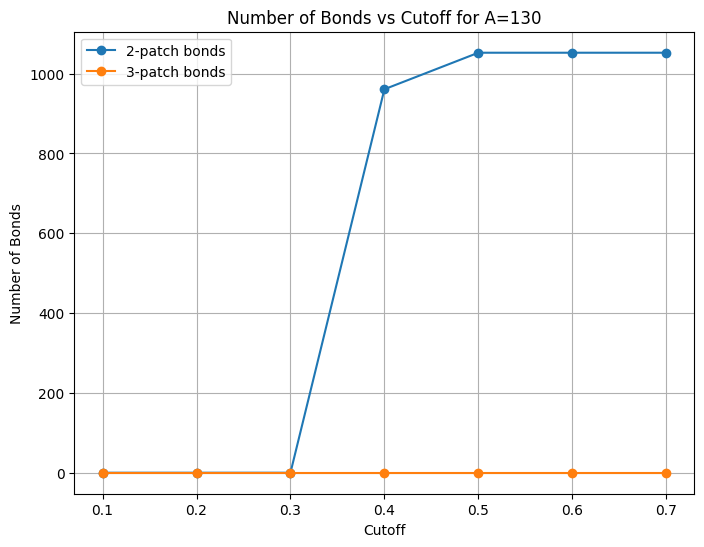

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


for A in [80, 90, 100, 110, 120, 130]:
    two_patch_bond_list = []
    three_patch_bond_list = []
    for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
        filename = f"data/patches/{cutoff}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
        N_patches = 4000
        frame = 11

        # with open(filename, "r") as file:
        #     for i in range((frame - 1) * (9 + N_patches) + 1):
        #         line = file.readline()
        #     print("Timestep:", file.readline())

        df = pd.read_csv(filename, skiprows=frame*9+(frame - 1) * N_patches, sep=' ', nrows=N_patches, header=None, names=["id", "mol", "x", "y", "z", "patch_coord", "patch_cluster"])
        df.sort_values(by=["patch_coord", "id"], ascending=True, inplace=True)

        patch_cluster_list = np.unique(df["patch_cluster"].values)
        cluster_size_list = np.zeros(len(patch_cluster_list))

        for i, patch_cluster in enumerate(patch_cluster_list):
            this_patch = df[df["patch_cluster"] == patch_cluster]
            cluster_size_list[i] = np.max(this_patch[["patch_coord"]].values) + 1

        two_patch_bond_list.append(np.sum(cluster_size_list == 2)/2)
        three_patch_bond_list.append(np.sum(cluster_size_list == 3)/3)
    
    figure = plt.figure(figsize=(8, 6))
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], two_patch_bond_list, marker='o', label="2-patch bonds")
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7], three_patch_bond_list, marker='o', label="3-patch bonds")
    plt.title(f"Number of Bonds vs Cutoff for A={A}")
    plt.xlabel("Cutoff")
    plt.ylabel("Number of Bonds")
    plt.grid()
    plt.legend()
    plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lifetime object:
#   - bonded_pair: (id1, id2)
#   - start_time: timestep when bond is formed
#   - end_time: timestep when bond breaks
#   - lifetime: end_time - start_time

# Read frame
# Filter only consider bonds with at least 1 patch
# sort by patch_cluster (get bonded pairs)
# Create broken flag list for all current bonded pairs
# if already existing in bonded pairs, set flag to false
# if not existing, add to bonded pairs and start counting lifetime until it breaks (patch_coord goes to 0)
# all pairs that have broken flag true, set end_time to current timestep, calculate lifetime, and remove from bonded pairs
"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_lifetimes(filename, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    with open(filename, 'r') as f:
        time = 0
        while True:
            line = f.readline()
            if not line:
                break
            if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                time = float(f.readline().strip()) * timestep # convert to time units
                # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
            elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                N_patches = int(f.readline().strip())
            elif line.startswith("ITEM: ATOMS"): # data starts on next line
                current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                for i in range(N_patches):
                    clusters[i] = np.array(f.readline().strip().split(), dtype=float)
                # filter only consider bonds with at least 1 patch
                clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                # sort by patch_cluster (get bonded pairs) 
                clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                for i in range(len(clusters)-1):
                    id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                    if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                        ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                        current_bonds.add(ids) # add to current bonds set
                
                for ids in current_bonds:
                    if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                        bonded_pairs[ids] = time
                
                broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                for ids in broken_bonds:
                    start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                    lifetime = time - start_time
                    if (lifetime > timestep):
                        bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                
                # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                # print(bond_lifetimes)
    return bond_lifetimes



In [ ]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [130]

def process_and_save_lifetimes(cutoff, A):
    start = time()
    # filename = f"data/patches/{cutoff}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    # lifetimes = process_lifetimes(filename)
    # lifetimes_df = pd.DataFrame(lifetimes, columns=["id1", "id2", "start_time", "end_time", "lifetime"])
    # lifetimes_df.to_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv", index=False)
    # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)} in {time() - start:.2f} seconds")

finish = Parallel(n_jobs=-1)(delayed(process_and_save_lifetimes)(cutoff, A) for cutoff in cutoffs for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


Processed lifetimes for A=130, cutoff=0.7, total lifetimes recorded: 18858 in 1057.21 seconds
Processed lifetimes for A=130, cutoff=0.6, total lifetimes recorded: 6718 in 1062.70 seconds
Processed lifetimes for A=130, cutoff=0.5, total lifetimes recorded: 30465 in 1065.06 seconds
Processed lifetimes for A=130, cutoff=0.4, total lifetimes recorded: 20441141 in 1081.94 seconds


/tmp/ipykernel_1139731/758604315.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


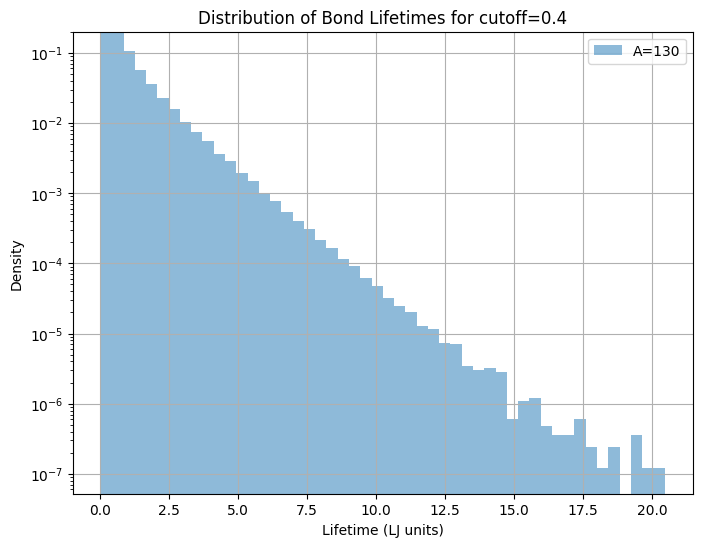

/tmp/ipykernel_1139731/758604315.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


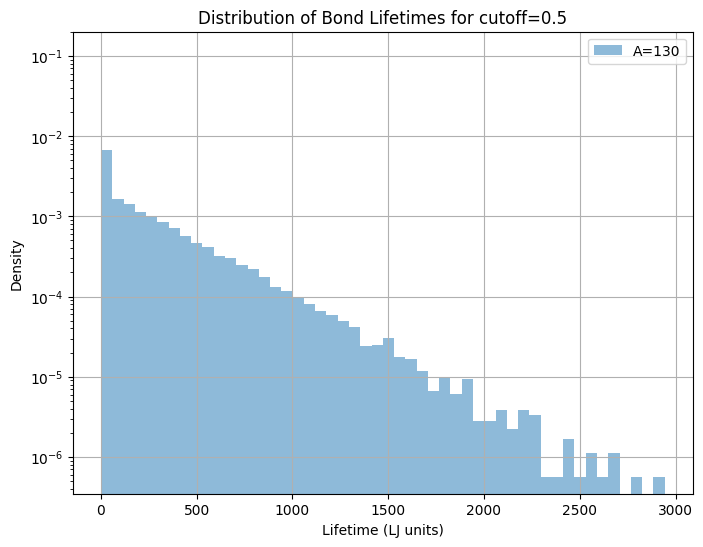

/tmp/ipykernel_1139731/758604315.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


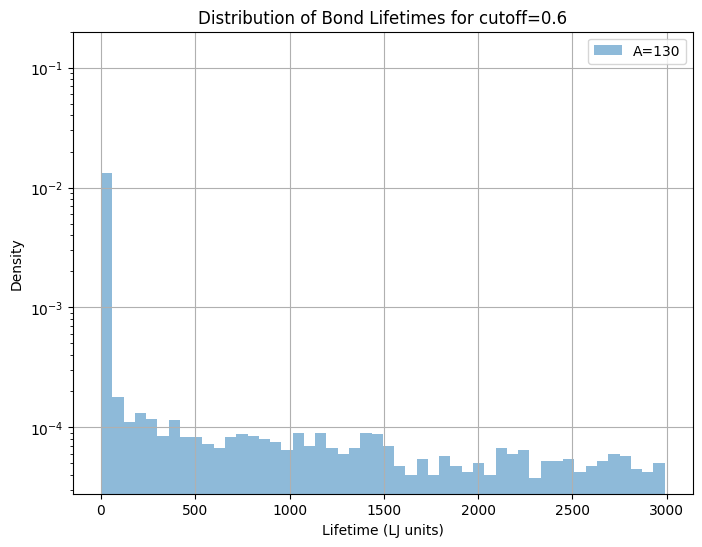

/tmp/ipykernel_1139731/758604315.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 0.2)


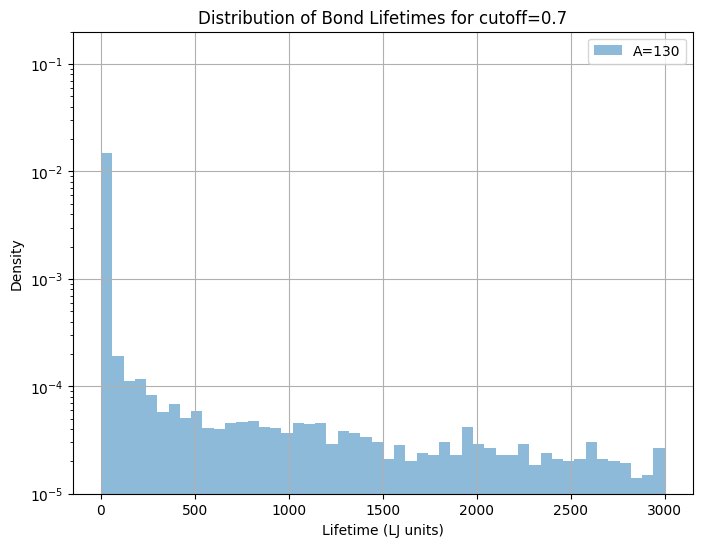

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()

for cutoff in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for A in [130]:
        df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
        lifetimes = np.array(df["lifetime"].values)
        # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

        values, counts = np.unique(lifetimes, return_counts=True)


        plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    plt.ylim(0, 0.2)
    plt.grid()
    plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
    plt.legend()
    plt.show()

## Lifetime algorithm with different $r_{\text{on}}, r_{\text{off}}$

With different radii for forming/breaking a bond, we should avoid jitter close to one cutoff that result in tiny lifetimes. This does require generating and reading two clustering dumps, but we can dump both in one file so we at least won't have too many files.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# lifetime object:
#   - bonded_pair: (id1, id2)
#   - start_time: timestep when bond is formed
#   - end_time: timestep when bond breaks
#   - lifetime: end_time - start_time

# Read frame
# Filter only consider bonds with at least 1 patch
# sort by patch_cluster (get bonded pairs)
# Create broken flag list for all current bonded pairs
# if already existing in bonded pairs, set flag to false
# if not existing, add to bonded pairs and start counting lifetime until it breaks (patch_coord goes to 0)
# all pairs that have broken flag true, set end_time to current timestep, calculate lifetime, and remove from bonded pairs
"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - bond_lifetimes: list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair
"""
def process_buffered_lifetimes(filename_on, filename_off, timestep=0.002):
    # init empty bond lifetime list
    bond_lifetimes = []
    # init empty bonded pair dict. lookup by (id1, id2) where id1 < id2 to avoid duplicates. value is start_time of the bond
    bonded_pairs = {}
    with open(filename_on, 'r') as f_on:
        with open(filename_off, 'r') as f_off:
            time = 0
            while True:
                # stop reading BOTH if either file is done
                # reading f_on, only creating bonds
                line = f_on.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_on.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_on.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                    clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                    for i in range(N_patches):
                        clusters[i] = np.array(f_on.readline().strip().split(), dtype=float)
                    # filter only consider bonds with at least 1 patch
                    clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                    # sort by patch_cluster (get bonded pairs) 
                    clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                    for i in range(len(clusters)-1):
                        id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                        if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                            ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                            current_bonds.add(ids) # add to current bonds set
                    
                    for ids in current_bonds:
                        if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                            bonded_pairs[ids] = time
                    
                    ### broken bonds handled by f_off
                    # broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    # for ids in broken_bonds:
                    #     start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                    #     lifetime = time - start_time
                    #     if (lifetime > timestep):
                    #         bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
                    # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                    # print(bond_lifetimes)

                # reading f_off, only breaking bonds
                line = f_off.readline()
                if not line:
                    break
                if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                    time = float(f_off.readline().strip()) * timestep # convert to time units
                    # print(f"Processing timestep: {time / timestep:.0f} (time units: {time})")
                elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                    N_patches = int(f_off.readline().strip())
                elif line.startswith("ITEM: ATOMS"): # data starts on next line
                    current_bonds = set() # track current bonded pairs in this frame to compare with bonded_pairs dict
                    clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                    for i in range(N_patches):
                        clusters[i] = np.array(f_off.readline().strip().split(), dtype=float)
                    # filter only consider bonds with at least 1 patch
                    clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                    # sort by patch_cluster (get bonded pairs) 
                    clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                    for i in range(len(clusters)-1):
                        id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                        if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                            ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                            current_bonds.add(ids) # add to current bonds set
                    
                    ### creating bonds handled by f_on
                    # for ids in current_bonds:
                    #     if ids not in bonded_pairs: # if new bond, add to bonded_pairs dict with start_time as current timestep
                    #         bonded_pairs[ids] = time
                    
                    broken_bonds = set(bonded_pairs.keys()) - current_bonds # bonds that are in bonded_pairs but not in current_bonds are broken
                    for ids in broken_bonds:
                        start_time = bonded_pairs.pop(ids) # remove from bonded_pairs and get start_time
                        lifetime = time - start_time
                        if (lifetime > timestep):
                            bond_lifetimes.append((*ids, start_time, time, lifetime)) # add to bond_lifetimes list
                    
                    # print(f"Current bonded pairs: {len(bonded_pairs)}, Total bond lifetimes recorded: {len(bond_lifetimes)}")
                    # print(bond_lifetimes)
    return bond_lifetimes



In [ ]:
from joblib import Parallel, delayed
from time import time

# cutoffs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [110, 120]

def process_and_save_lifetimes(cutoff_on, cutoff_off, A):
    start = time()
    filename_on = f"data/patches/{cutoff_on}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    filename_off = f"data/patches/{cutoff_off}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    lifetimes = process_buffered_lifetimes(filename_on, filename_off)
    lifetimes_df = pd.DataFrame(lifetimes, columns=["id1", "id2", "start_time", "end_time", "lifetime"])
    lifetimes_df.to_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv", index=False)
    print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)} in {time() - start:.2f} seconds")

# only process lifetimes for cutoff_on < cutoff_off to avoid duplicates
finish = Parallel(n_jobs=6)(delayed(process_and_save_lifetimes)(cutoff_on, cutoff_off, A) for cutoff_on in cutoffs for cutoff_off in cutoffs if cutoff_on < cutoff_off for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 991826 in 547.38 seconds
Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 161901 in 549.72 seconds
Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 129772 in 551.38 seconds
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 188815 in 591.08 seconds
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 174450 in 592.17 seconds
Processed lifetimes for A=90, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 221405 in 595.08 seconds


Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.4, total lifetimes recorded: 6851684


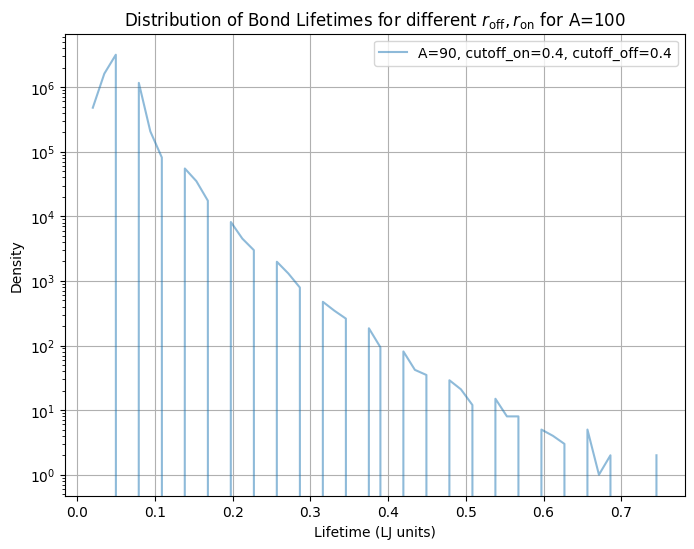

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 991826
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 1108905


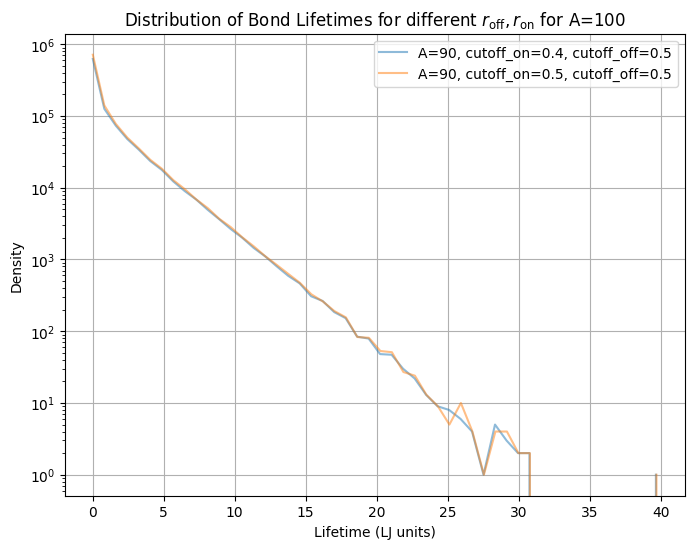

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 161901
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 188815
Processed lifetimes for A=90, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 244020


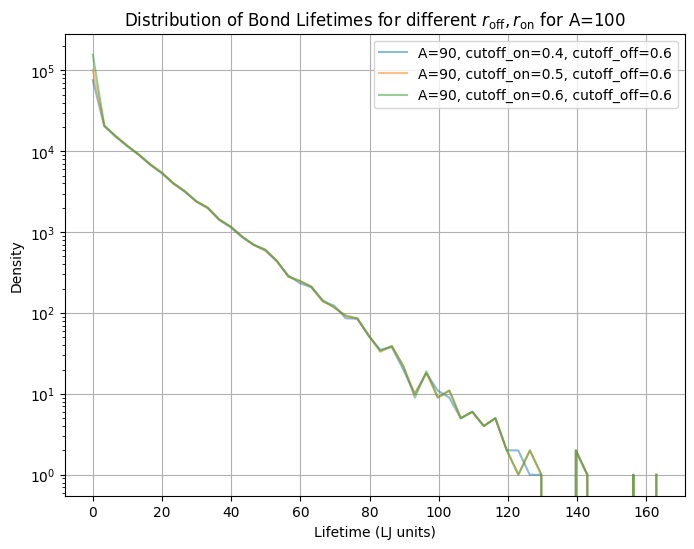

Processed lifetimes for A=90, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 129772
Processed lifetimes for A=90, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 174450
Processed lifetimes for A=90, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 221405
Processed lifetimes for A=90, cutoff_on=0.7, cutoff_off=0.7, total lifetimes recorded: 412921


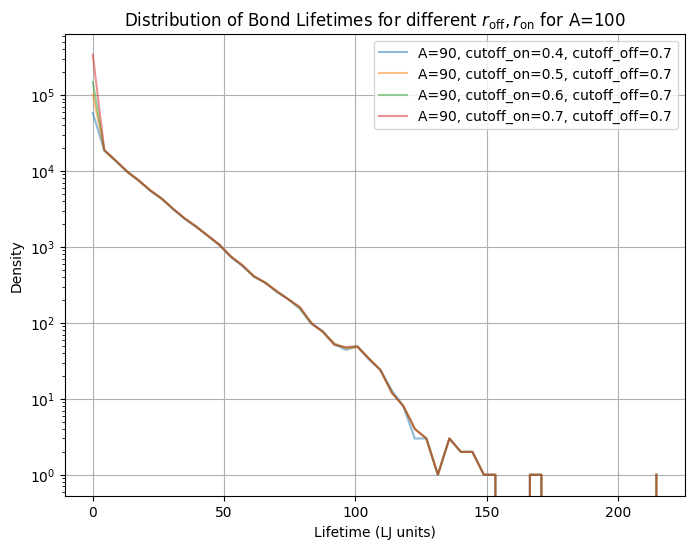

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()

for cutoff_off in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for cutoff_on in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on < cutoff_off:
            for A in [90]:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
        if cutoff_on == cutoff_off:
            for A in [90]:
                df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff_on}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    # plt.ylim(0, 0.2)
    plt.grid()
    plt.title(r"Distribution of Bond Lifetimes for different $r_{\text{off}}, r_{\text{on}}$ for A=100")
    plt.legend()
    plt.show()

Processed lifetimes for A=120, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 48132
Removing, remaining lifetimes recorded: 28430
Fitted coefficients for A=120, cutoff_on=0.4, cutoff_off=0.5: [2.80006265e+03 1.38216188e-02 2.93496410e+03 1.38216218e-02]
Fitted lifetimes for A=120, cutoff_on=0.4, cutoff_off=0.5: tau_1=72.35, tau_2=72.35


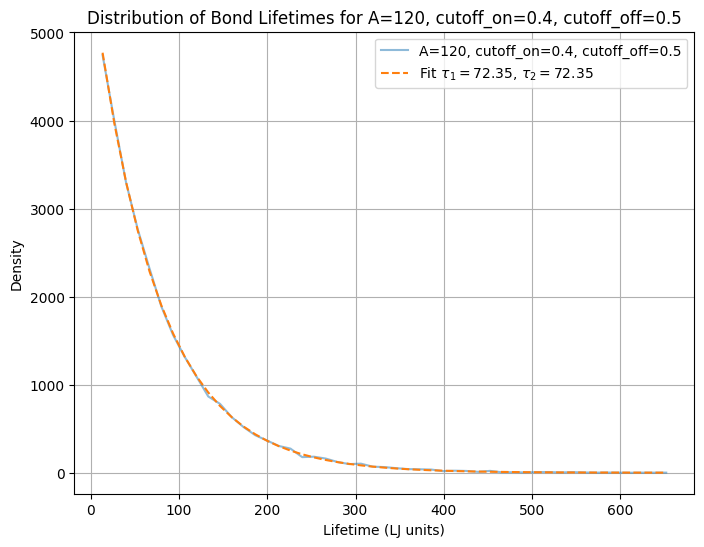

Processed lifetimes for A=120, cutoff_on=0.5, cutoff_off=0.5, total lifetimes recorded: 50046
Removing, remaining lifetimes recorded: 28446
Fitted coefficients for A=120, cutoff_on=0.5, cutoff_off=0.5: [3.02191764e+03 1.38197980e-02 2.71578378e+03 1.38197980e-02]
Fitted lifetimes for A=120, cutoff_on=0.5, cutoff_off=0.5: tau_1=72.36, tau_2=72.36


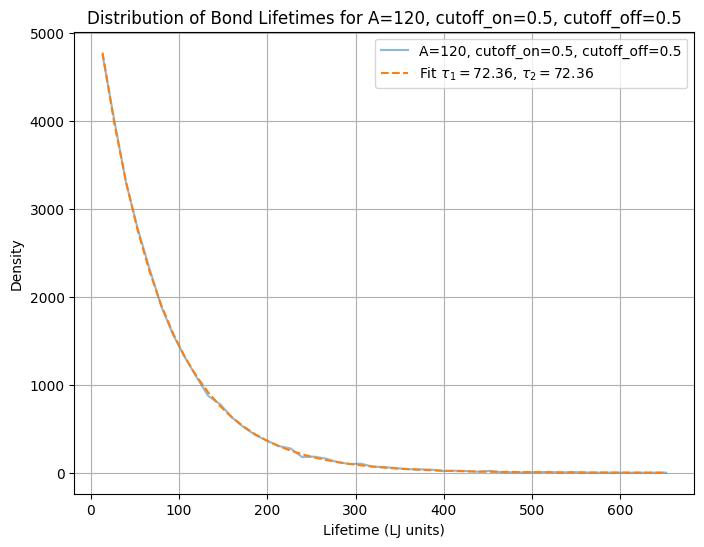

Processed lifetimes for A=120, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 2790
Removing, remaining lifetimes recorded: 2169
Fitted coefficients for A=120, cutoff_on=0.4, cutoff_off=0.6: [6.27528856e+01 4.74567030e-02 7.93120418e+01 1.34671311e-03]
Fitted lifetimes for A=120, cutoff_on=0.4, cutoff_off=0.6: tau_1=21.07, tau_2=742.55


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

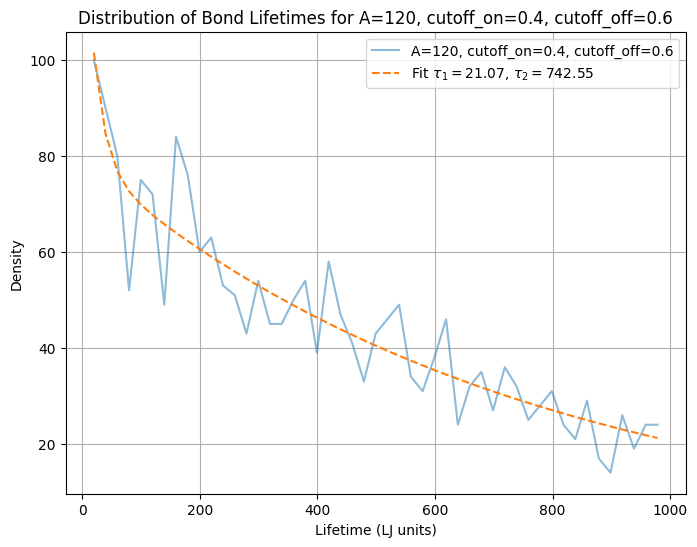

Processed lifetimes for A=120, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 4050
Removing, remaining lifetimes recorded: 2169
Fitted coefficients for A=120, cutoff_on=0.5, cutoff_off=0.6: [5.85844408e+01 4.55648159e-02 7.93366944e+01 1.34723678e-03]
Fitted lifetimes for A=120, cutoff_on=0.5, cutoff_off=0.6: tau_1=21.95, tau_2=742.26


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


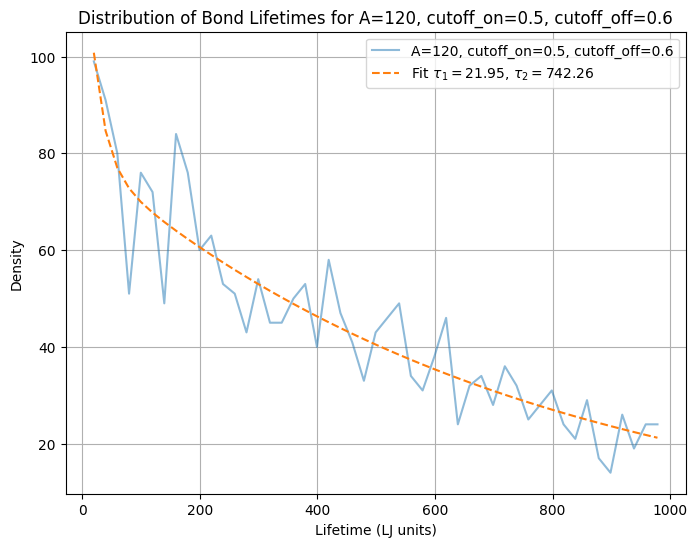

Processed lifetimes for A=120, cutoff_on=0.6, cutoff_off=0.6, total lifetimes recorded: 7102
Removing, remaining lifetimes recorded: 2169
Fitted coefficients for A=120, cutoff_on=0.6, cutoff_off=0.6: [5.85844408e+01 4.55648159e-02 7.93366944e+01 1.34723678e-03]
Fitted lifetimes for A=120, cutoff_on=0.6, cutoff_off=0.6: tau_1=21.95, tau_2=742.26


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


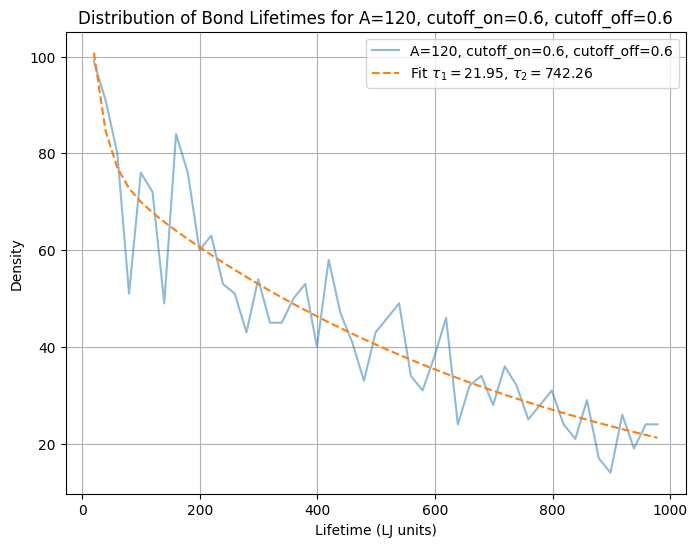

Processed lifetimes for A=120, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 5662
Removing, remaining lifetimes recorded: 3071
Fitted coefficients for A=120, cutoff_on=0.4, cutoff_off=0.7: [2.37289676e+02 2.49627214e-02 1.23182597e+02 1.89147987e-03]
Fitted lifetimes for A=120, cutoff_on=0.4, cutoff_off=0.7: tau_1=40.06, tau_2=528.69


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


<Figure size 800x600 with 0 Axes>

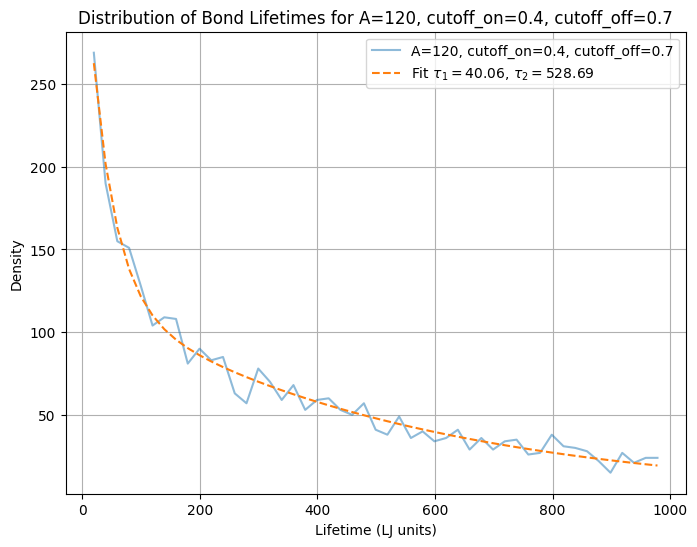

Processed lifetimes for A=120, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 7256
Removing, remaining lifetimes recorded: 3071


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


Fitted coefficients for A=120, cutoff_on=0.5, cutoff_off=0.7: [1.23182615e+02 1.89144227e-03 2.37289716e+02 2.49622323e-02]
Fitted lifetimes for A=120, cutoff_on=0.5, cutoff_off=0.7: tau_1=40.06, tau_2=528.70


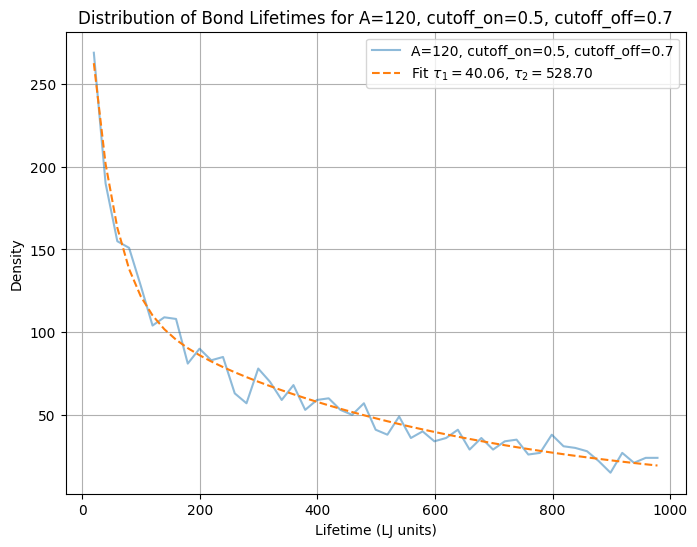

Processed lifetimes for A=120, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 9788
Removing, remaining lifetimes recorded: 3071
Fitted coefficients for A=120, cutoff_on=0.6, cutoff_off=0.7: [2.36442606e+02 2.48661937e-02 1.23127714e+02 1.89066761e-03]
Fitted lifetimes for A=120, cutoff_on=0.6, cutoff_off=0.7: tau_1=40.22, tau_2=528.91


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)
/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in multiply
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


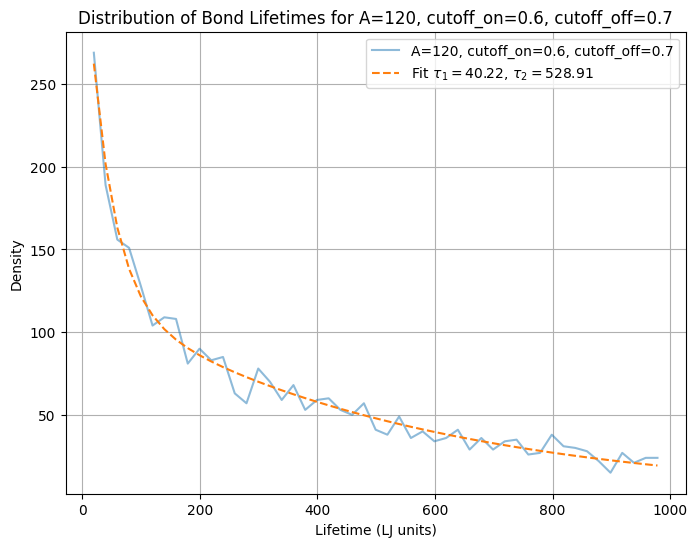

Processed lifetimes for A=120, cutoff_on=0.7, cutoff_off=0.7, total lifetimes recorded: 21051
Removing, remaining lifetimes recorded: 3071
Fitted coefficients for A=120, cutoff_on=0.7, cutoff_off=0.7: [2.36434448e+02 2.48576435e-02 1.23101519e+02 1.89020182e-03]
Fitted lifetimes for A=120, cutoff_on=0.7, cutoff_off=0.7: tau_1=40.23, tau_2=529.04


/tmp/ipykernel_1289448/1912001027.py:8: RuntimeWarning: overflow encountered in exp
  return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)


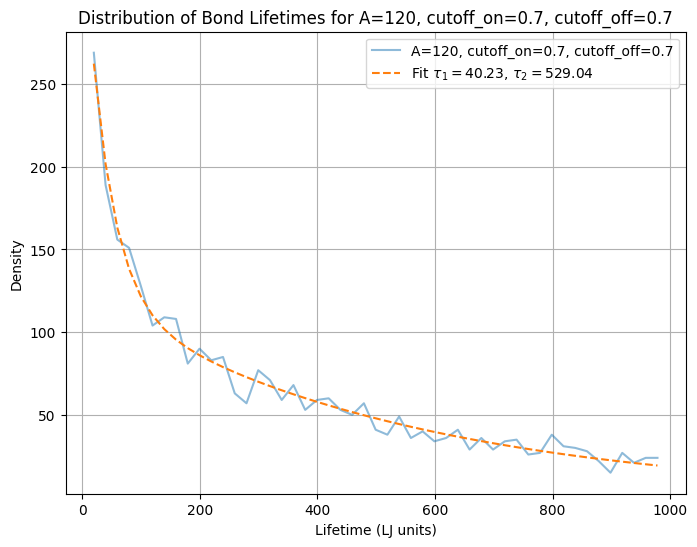

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def biexponential(x, a1, b1, a2, b2):
    return a1 * np.exp(-b1 * x) + a2 * np.exp(-b2 * x)

def single_exponential(x, a, b):
    return a * np.exp(-b * x)




for cutoff_off in [ 0.5, 0.6, 0.7]:
    for cutoff_on in [0.4, 0.5, 0.6, 0.7]:
        fig = plt.figure(figsize=(8, 6))
        if cutoff_on < cutoff_off:
            for A in [120]:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=10000)
                print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}")

                # coeffs, cov = curve_fit(single_exponential, bins[:-1], hist, p0=[1, 0.01])
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                # plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                # plt.plot(bins[:-1], single_exponential(bins[:-1], *coeffs), '--', label=f"Fit A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            
            plt.xlabel("Lifetime (LJ units)")
            plt.ylabel("Density")
            # plt.yscale("log")
            # plt.ylim(0, 0.2)
            plt.grid()
            plt.title(f"Distribution of Bond Lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            plt.legend()
            plt.show()
            
        if cutoff_on == cutoff_off:
            for A in [120]:
                df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff_on}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)
                hist, bins = np.histogram(lifetimes, bins=50)


                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
                hist = hist[1:] # remove first bin
                bins = bins[1:] # remove first bin
                print(f"Removing, remaining lifetimes recorded: {np.sum(hist)}")

                coeffs, cov = curve_fit(biexponential, bins[:-1], hist, p0=[1, 0.01, 1, 0.01], maxfev=10000)
                print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                tau_1, tau_2 = sorted((1/coeffs[1], 1/coeffs[3]))
                print(f"Fitted lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: tau_1={tau_1:.2f}, tau_2={tau_2:.2f}")

                
                plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                plt.plot(bins[:-1], biexponential(bins[:-1], *coeffs), '--', label=r"Fit $\tau_1=$" + f"{tau_1:.2f}" + r", $\tau_2=$" + f"{tau_2:.2f}")

                # coeffs, cov = curve_fit(single_exponential, bins[:-1], hist, p0=[1, 0.01])
                # print(f"Fitted coefficients for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}: {coeffs}")
                # plt.plot(bins[:-1], hist, alpha=0.5, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                # plt.plot(bins[:-1], single_exponential(bins[:-1], *coeffs), '--', label=f"Fit A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                
            plt.xlabel("Lifetime (LJ units)")
            plt.ylabel("Density")
            # plt.yscale("log")
            # plt.ylim(0, 0.2)
            plt.grid()
            plt.title(f"Distribution of Bond Lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
            plt.legend()
            plt.show()

Processed lifetimes for A=100, cutoff_on=0.4, cutoff_off=0.5, total lifetimes recorded: 570528
Processed lifetimes for A=100, cutoff_on=0.4, cutoff_off=0.6, total lifetimes recorded: 59646
Processed lifetimes for A=100, cutoff_on=0.4, cutoff_off=0.7, total lifetimes recorded: 59891
Processed lifetimes for A=100, cutoff_on=0.5, cutoff_off=0.6, total lifetimes recorded: 70810
Processed lifetimes for A=100, cutoff_on=0.5, cutoff_off=0.7, total lifetimes recorded: 83394
Processed lifetimes for A=100, cutoff_on=0.6, cutoff_off=0.7, total lifetimes recorded: 108486


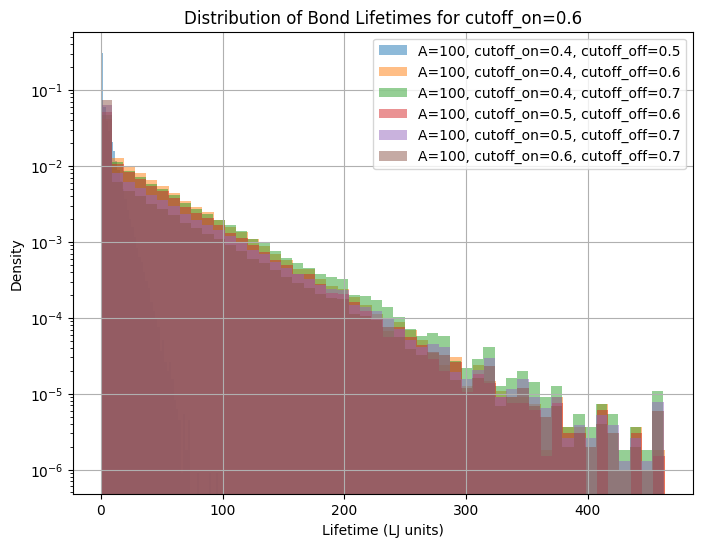

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for cutoff in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
#     fig = plt.figure(figsize=(8, 6))
#     for A in [50, 60, 70, 80, 90, 100]:
#         df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
#         lifetimes = np.array(df["lifetime"].values)
#         # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

#         values, counts = np.unique(lifetimes, return_counts=True)


#         plt.hist(values, weights=counts, bins=50, alpha=0.5, label=f"A={A}", density=True)
#     plt.xlabel("Lifetime (LJ units)")
#     plt.ylabel("Counts")
#     plt.grid()
#     plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
#     plt.legend()
#     plt.show()
fig = plt.figure(figsize=(8, 6))
for cutoff_on in [0.4, 0.5, 0.6]:
    
    for cutoff_off in [0.4, 0.5, 0.6, 0.7]:
        if cutoff_on < cutoff_off:
            for A in [100]:
                df = pd.read_csv(f"data/lifetimes/buffered_lifetimes_A{A}_cutoff_on{cutoff_on}_cutoff_off{cutoff_off}_r0_0.25.csv")
                lifetimes = np.array(df["lifetime"].values)
                # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

                # values, counts = np.unique(lifetimes, return_counts=True)


                plt.hist(lifetimes, bins=50, alpha=0.5,density=True, label=f"A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}")
                print(f"Processed lifetimes for A={A}, cutoff_on={cutoff_on}, cutoff_off={cutoff_off}, total lifetimes recorded: {len(lifetimes)}")
plt.xlabel("Lifetime (LJ units)")
plt.ylabel("Density")
plt.yscale("log")
# plt.ylim(0, 0.2)
plt.grid()
plt.title(f"Distribution of Bond Lifetimes for cutoff_on={cutoff_on}")
plt.legend()
plt.show()

## Fit to exponential decay to get characteristic lifetime for each A and cutoff

We bin the data, then take the later 95% to remove the peaked low lifetime bonds. We can then fit that to a biexponential decay and see what the larger time constant is.

Processed lifetimes for A=130, cutoff=0.4, total lifetimes recorded: 20441141, after removing first 10% of lifetime range : 20441141


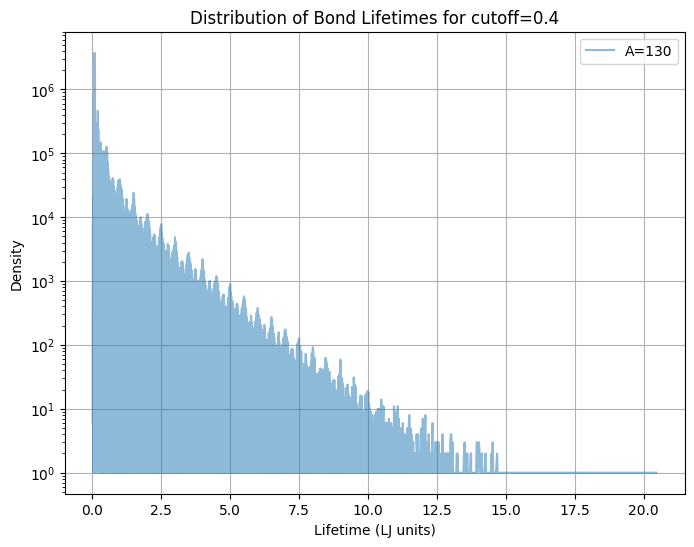

Processed lifetimes for A=130, cutoff=0.5, total lifetimes recorded: 30465, after removing first 10% of lifetime range : 30465


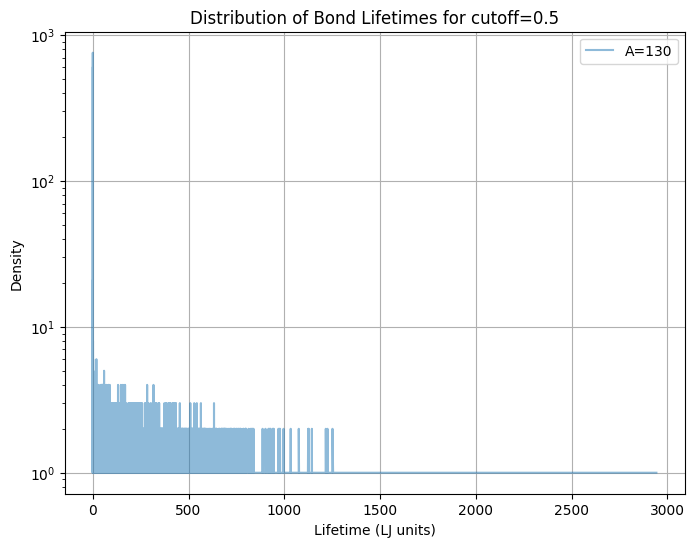

Processed lifetimes for A=130, cutoff=0.6, total lifetimes recorded: 6718, after removing first 10% of lifetime range : 6718


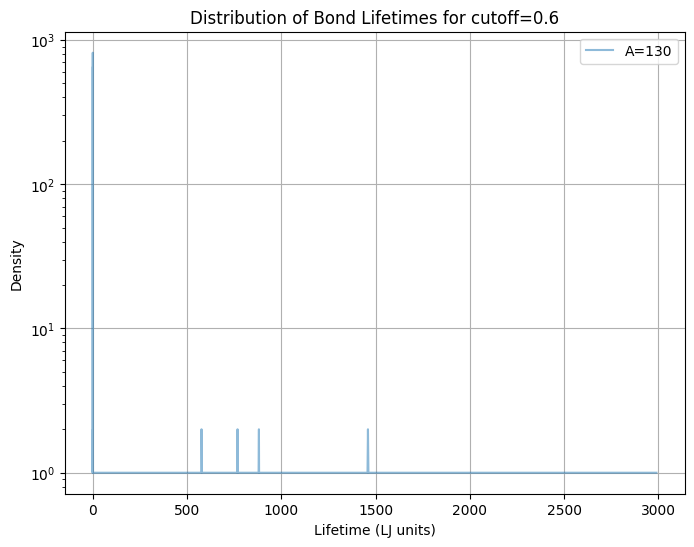

Processed lifetimes for A=130, cutoff=0.7, total lifetimes recorded: 18858, after removing first 10% of lifetime range : 18858


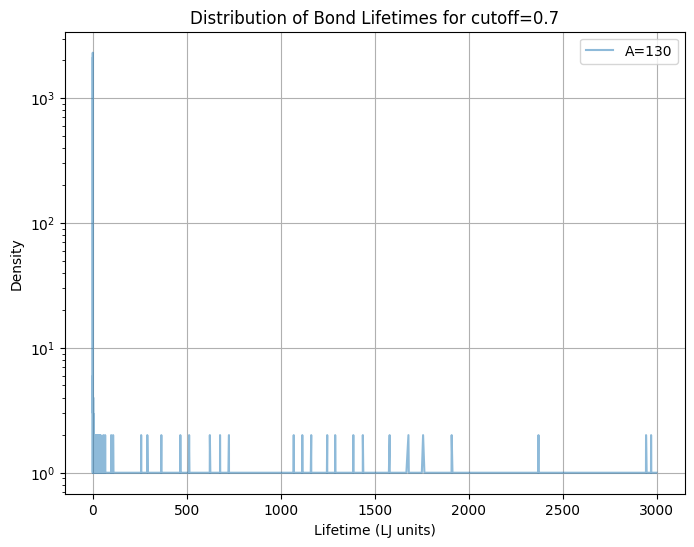

In [22]:
for cutoff in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for A in [130]:
        df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
        lifetimes = np.array(df["lifetime"].values)
        # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")

        values, counts = np.unique(lifetimes, return_counts=True)

        # remove first 10% of data to remove the peak at low lifetimes
        cutoff_index = int(len(values) * 0.00)
        values = values[cutoff_index:]
        counts = counts[cutoff_index:]
        print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}, after removing first 10% of lifetime range : {np.sum(counts)}")


        plt.plot(values, counts, alpha=0.5, label=f"A={A}")
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Density")
    plt.yscale("log")
    # plt.ylim(0, 0.2)
    plt.grid()
    plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
    plt.legend()
    plt.show()

[1.6230563e+07 1.9136650e+06 8.9444800e+05 4.7043200e+05 3.0237200e+05
 1.8686700e+05 1.3269800e+05 8.7169000e+04 6.1835000e+04 4.5770000e+04
 3.0721000e+04 2.3649000e+04 1.6287000e+04 1.2373000e+04 8.4460000e+03
 6.4270000e+03 4.5640000e+03 3.3400000e+03 2.5610000e+03 1.7950000e+03
 1.3690000e+03 9.8000000e+02 7.6000000e+02 5.2100000e+02 4.0200000e+02
 2.7200000e+02 2.0800000e+02 1.6800000e+02 1.0700000e+02 9.7000000e+01
 6.1000000e+01 6.0000000e+01 2.9000000e+01 2.5000000e+01 2.7000000e+01
 2.4000000e+01 5.0000000e+00 9.0000000e+00 1.0000000e+01 4.0000000e+00
 3.0000000e+00 3.0000000e+00 5.0000000e+00 2.0000000e+00 1.0000000e+00
 2.0000000e+00 0.0000000e+00 3.0000000e+00 1.0000000e+00 1.0000000e+00] [2.00000e-02 4.28800e-01 8.37600e-01 1.24640e+00 1.65520e+00 2.06400e+00
 2.47280e+00 2.88160e+00 3.29040e+00 3.69920e+00 4.10800e+00 4.51680e+00
 4.92560e+00 5.33440e+00 5.74320e+00 6.15200e+00 6.56080e+00 6.96960e+00
 7.37840e+00 7.78720e+00 8.19600e+00 8.60480e+00 9.01360e+00 9.42240e+

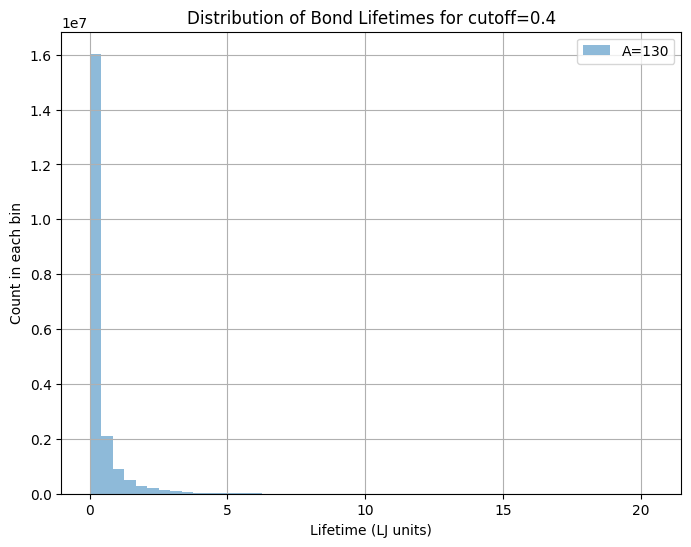

[1.1992e+04 2.9820e+03 2.5190e+03 2.0270e+03 1.7900e+03 1.5290e+03
 1.2770e+03 1.0310e+03 8.3600e+02 7.4200e+02 5.8200e+02 5.3600e+02
 4.3800e+02 3.9000e+02 3.1200e+02 2.3400e+02 2.0800e+02 1.7700e+02
 1.4300e+02 1.1800e+02 1.0600e+02 8.9000e+01 7.5000e+01 4.4000e+01
 4.5000e+01 5.5000e+01 3.2000e+01 3.0000e+01 2.1000e+01 1.2000e+01
 1.8000e+01 1.1000e+01 1.7000e+01 5.0000e+00 5.0000e+00 7.0000e+00
 4.0000e+00 7.0000e+00 6.0000e+00 1.0000e+00 1.0000e+00 3.0000e+00
 1.0000e+00 2.0000e+00 1.0000e+00 2.0000e+00 0.0000e+00 1.0000e+00
 0.0000e+00 1.0000e+00] [2.0000000e-02 5.8879600e+01 1.1773920e+02 1.7659880e+02 2.3545840e+02
 2.9431800e+02 3.5317760e+02 4.1203720e+02 4.7089680e+02 5.2975640e+02
 5.8861600e+02 6.4747560e+02 7.0633520e+02 7.6519480e+02 8.2405440e+02
 8.8291400e+02 9.4177360e+02 1.0006332e+03 1.0594928e+03 1.1183524e+03
 1.1772120e+03 1.2360716e+03 1.2949312e+03 1.3537908e+03 1.4126504e+03
 1.4715100e+03 1.5303696e+03 1.5892292e+03 1.6480888e+03 1.7069484e+03
 1.7658080e+03

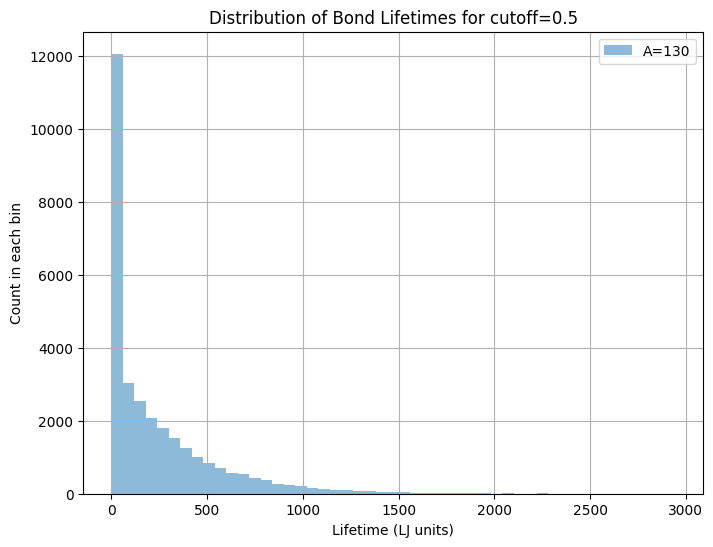

[5350.   72.   44.   53.   47.   34.   46.   33.   33.   29.   27.   33.
   35.   34.   32.   30.   26.   36.   28.   36.   27.   24.   27.   36.
   35.   28.   19.   16.   22.   16.   23.   19.   17.   20.   16.   27.
   24.   26.   15.   21.   21.   22.   17.   19.   21.   24.   23.   18.
   17.   20.] [2.0000000e-02 5.9796400e+01 1.1957280e+02 1.7934920e+02 2.3912560e+02
 2.9890200e+02 3.5867840e+02 4.1845480e+02 4.7823120e+02 5.3800760e+02
 5.9778400e+02 6.5756040e+02 7.1733680e+02 7.7711320e+02 8.3688960e+02
 8.9666600e+02 9.5644240e+02 1.0162188e+03 1.0759952e+03 1.1357716e+03
 1.1955480e+03 1.2553244e+03 1.3151008e+03 1.3748772e+03 1.4346536e+03
 1.4944300e+03 1.5542064e+03 1.6139828e+03 1.6737592e+03 1.7335356e+03
 1.7933120e+03 1.8530884e+03 1.9128648e+03 1.9726412e+03 2.0324176e+03
 2.0921940e+03 2.1519704e+03 2.2117468e+03 2.2715232e+03 2.3312996e+03
 2.3910760e+03 2.4508524e+03 2.5106288e+03 2.5704052e+03 2.6301816e+03
 2.6899580e+03 2.7497344e+03 2.8095108e+03 2.8692872e+0

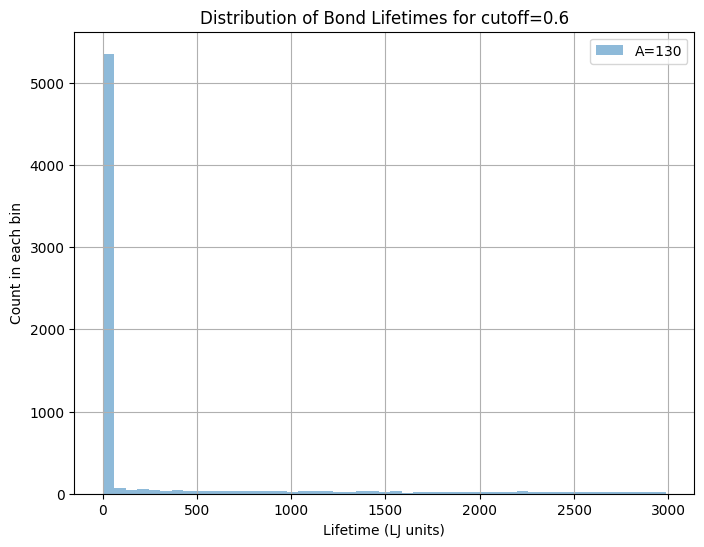

[1.6624e+04 2.1600e+02 1.2600e+02 1.3200e+02 9.4000e+01 6.5000e+01
 7.8000e+01 5.7000e+01 6.7000e+01 4.6000e+01 4.5000e+01 5.1000e+01
 5.3000e+01 5.4000e+01 4.7000e+01 4.6000e+01 4.2000e+01 5.1000e+01
 5.0000e+01 5.2000e+01 3.3000e+01 4.3000e+01 4.2000e+01 3.8000e+01
 3.4000e+01 2.4000e+01 3.2000e+01 2.3000e+01 2.7000e+01 2.6000e+01
 3.4000e+01 2.6000e+01 4.7000e+01 3.3000e+01 3.0000e+01 2.6000e+01
 2.6000e+01 3.3000e+01 2.1000e+01 2.7000e+01 2.4000e+01 2.3000e+01
 2.4000e+01 3.4000e+01 2.4000e+01 2.3000e+01 2.2000e+01 1.6000e+01
 1.7000e+01 3.0000e+01] [2.0000000e-02 5.9987200e+01 1.1995440e+02 1.7992160e+02 2.3988880e+02
 2.9985600e+02 3.5982320e+02 4.1979040e+02 4.7975760e+02 5.3972480e+02
 5.9969200e+02 6.5965920e+02 7.1962640e+02 7.7959360e+02 8.3956080e+02
 8.9952800e+02 9.5949520e+02 1.0194624e+03 1.0794296e+03 1.1393968e+03
 1.1993640e+03 1.2593312e+03 1.3192984e+03 1.3792656e+03 1.4392328e+03
 1.4992000e+03 1.5591672e+03 1.6191344e+03 1.6791016e+03 1.7390688e+03
 1.7990360e+03

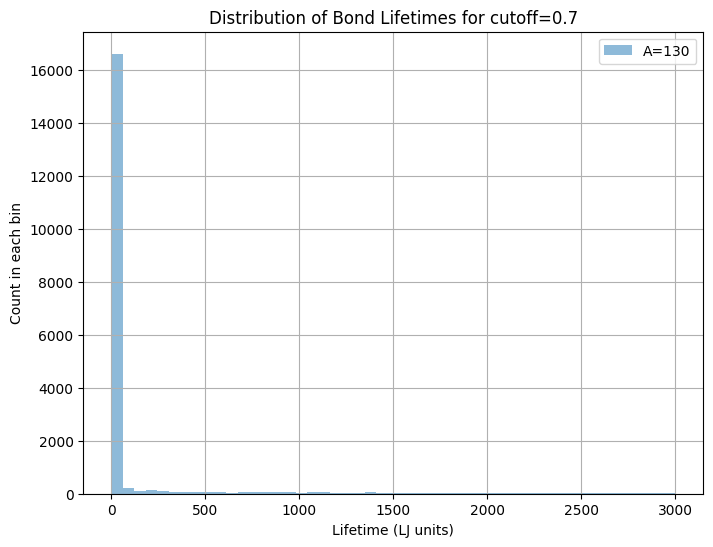

In [5]:
from scipy.stats import binned_statistic
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

for cutoff in [0.4, 0.5, 0.6, 0.7]:
    fig = plt.figure(figsize=(8, 6))
    for A in [130]:
        df = pd.read_csv(f"data/lifetimes/lifetimes_A{A}_cutoff{cutoff}_r0_0.25.csv")
        lifetimes = np.array(df["lifetime"].values)
        # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}")
        smallest_lifetime = np.min(lifetimes)
        largest_lifetime = np.max(lifetimes)

        # get number of lifetimes in each bin
        bin_means, bin_edges, binnumber = binned_statistic(lifetimes, lifetimes, bins=50, statistic='count')
        print(bin_means, bin_edges, binnumber)

        # # remove first 10% of data to remove the peak at low lifetimes
        # cutoff_index = int(len(result[0]) * 0.00)
        # values = result[1][:-1]
        # counts = result[0][cutoff_index:]
        # print(f"Processed lifetimes for A={A}, cutoff={cutoff}, total lifetimes recorded: {len(lifetimes)}, after removing first 10% of lifetime range : {np.sum(counts)}")


        plt.hist(lifetimes, bins=np.linspace(0, largest_lifetime, 50), alpha=0.5, label=f"A={A}")
        # plt.hist(lifetimes, bins=np.logspace(np.log10(smallest_lifetime), np.log10(largest_lifetime), 50), alpha=0.5, label=f"A={A}")
        # plt.hlines(bin_means[1:], bin_edges[1:-1], bin_edges[2:], alpha=0.5, label=f"A={A}", lw=5)
    plt.xlabel("Lifetime (LJ units)")
    plt.ylabel("Count in each bin")
    # plt.xscale("log")
    # plt.ylim(-0.2, 0.2)
    plt.grid()
    plt.title(f"Distribution of Bond Lifetimes for cutoff={cutoff}")
    plt.legend()
    plt.show()

## Alternative bond lifetime method (rate)

$$
N_\text{cumul}(t) = k \int_0^t N_\text{bound}(t') dt'
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


"""
Process lifetimes from clustering data file. Each frame of the file contains the following sections:
- "ITEM: TIMESTEP" followed by the timestep on the next line
- "ITEM: NUMBER OF ATOMS" followed by the number of entries on the next line
- "ITEM: ATOMS" followed by the data lines for each entry, with 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster

The bonded_pairs list is a dictionary where the key is a tuple of (id1, id2) with id1 < id2 to avoid duplicates, and the value is the 
start_time of the bond. 

The bond_lifetimes list is a list of tuples (id1, id2, start_time, end_time, lifetime) for each bonded pair that has broken.

If there are any bonded_pairs that have not broken by the end of the dump, we ignore them and do not record a lifetime for them.

All times for breaking/creating are considered on the timestep we note them, so we should on average get the right time 
(i.e. both events are noted AFTER they happen)

Args:
    - filename: path to the clustering data file
Returns:
    - N_bound: 
"""
def process_lifetimes(filename, timestep=0.002):
    N_cumul = {}
    N_bound = {}
    prev_timestep = None
    prev_bonds = set()  # track bonds present in previous frame to count unbinding events
    with open(filename, 'r') as f:
        time = 0
        while True:
            line = f.readline()
            if not line:
                break
            if line.startswith("ITEM: TIMESTEP"): # timestep is on next line
                time = float(f.readline().strip()) * timestep
                # print(f"Processing timestep: {time / timestep:.0f}")
            elif line.startswith("ITEM: NUMBER OF ATOMS"): # number of entries is on next line
                N_patches = int(f.readline().strip())
            elif line.startswith("ITEM: ATOMS"): # data starts on next line
                current_bonds = set() # track current bonded pairs in this frame to compare with previous frame
                clusters = np.zeros((N_patches,7)) # 7 values per line: id, mol, x, y, z, patch_coord, patch_cluster
                for i in range(N_patches):
                    clusters[i] = np.array(f.readline().strip().split(), dtype=float)
                # filter only consider bonds with at least 1 patch
                clusters = clusters[clusters[:,5] > 0] # patch_coord is in column 5
                # sort by patch_cluster (get bonded pairs) 
                clusters = clusters[clusters[:,6].argsort()] # patch_cluster is in column 6
                for i in range(len(clusters)-1):
                    id1, id2 = int(clusters[i][0]), int(clusters[i+1][0]) # get ids of current and next cluster
                    if clusters[i][6] == clusters[i+1][6]: # if same patch_cluster, they are bonded
                        ids = (id1, id2) if id1 < id2 else (id2, id1) # order ids to avoid duplicates
                        current_bonds.add(ids) # add to current bonds set
                
                # instantaneous number of bound pairs at this timestep
                N_bound[time] = len(current_bonds)

                # count number of unbinding (finished) events at this timestep: bonds present previously but gone now
                num_unbound = len(prev_bonds - current_bonds)
                if prev_timestep is None:
                    N_cumul[time] = num_unbound
                else:
                    N_cumul[time] = N_cumul[prev_timestep] + num_unbound

                # update trackers for next frame
                prev_bonds = current_bonds.copy()
                prev_timestep = time
    return N_bound, N_cumul




In [2]:
from joblib import Parallel, delayed
from time import time

cutoffs = [0.7, 0.6, 0.2, 0.3, 0.4, 0.5, 0.1]
# cutoffs = [0.4, 0.5, 0.6, 0.7]

As = [130, 120, 110, 100, 90, 80]

def process_and_save_lifetimes(cutoff, A):
    start = time()
    filename = f"data/patches/{cutoff}prodpatch_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{A}_r0_0.25_gaussB_10_seed_12345.bin.txt"
    N_bound, N_cumul = process_lifetimes(filename)
    N_bound_df = pd.DataFrame(N_bound.items(), columns=["time", "N_bound"])
    N_cumul_df = pd.DataFrame(N_cumul.items(), columns=["time", "N_cumul"])
    combined_df = pd.merge(N_bound_df, N_cumul_df, on="time")
    combined_df.to_csv(f"data/lifetimes/N_bound_cumul_A{A}_cutoff{cutoff}_r0_0.25.csv", index=False)
    print(f"Processed N_bound, N_cumul for A={A}, cutoff={cutoff}, in {time() - start:.2f} seconds")

finish = Parallel(n_jobs=10)(delayed(process_and_save_lifetimes)(cutoff, A) for cutoff in cutoffs for A in As)

# f = "data/patches/0.7prodpatch_chainlength_30_patchspacing_5_N_beads_24000_gaussA_45_r0_0.35_gaussB_10_seed_12345.bin.txt"

# lifetimes = process_lifetimes(f)


Processed N_bound, N_cumul for A=80, cutoff=0.7, in 291.15 seconds
Processed N_bound, N_cumul for A=100, cutoff=0.7, in 390.90 seconds
Processed N_bound, N_cumul for A=90, cutoff=0.7, in 391.47 seconds
Processed N_bound, N_cumul for A=120, cutoff=0.7, in 406.76 seconds
Processed N_bound, N_cumul for A=100, cutoff=0.6, in 417.44 seconds
Processed N_bound, N_cumul for A=120, cutoff=0.6, in 438.02 seconds
Processed N_bound, N_cumul for A=110, cutoff=0.6, in 438.77 seconds
Processed N_bound, N_cumul for A=130, cutoff=0.2, in 66.26 seconds
Processed N_bound, N_cumul for A=110, cutoff=0.7, in 595.52 seconds
Processed N_bound, N_cumul for A=90, cutoff=0.6, in 378.37 seconds
Processed N_bound, N_cumul for A=100, cutoff=0.2, in 248.27 seconds
Processed N_bound, N_cumul for A=80, cutoff=0.6, in 295.49 seconds
Processed N_bound, N_cumul for A=90, cutoff=0.2, in 248.23 seconds
Processed N_bound, N_cumul for A=80, cutoff=0.2, in 249.02 seconds
Processed N_bound, N_cumul for A=110, cutoff=0.2, in 32

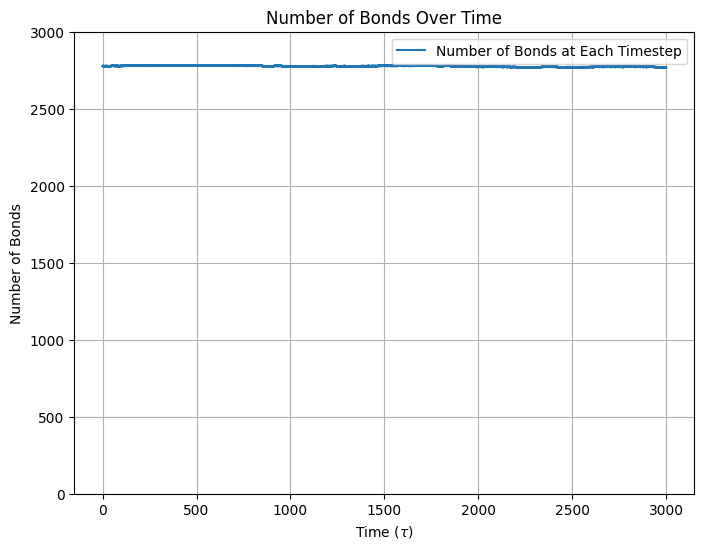

In [9]:
f = "data/lifetimes/N_bound_cumul_A130_cutoff0.5_r0_0.25.csv"
df = pd.read_csv(f)
N_bound = dict(zip(df["time"], df["N_bound"]))
N_cumul = dict(zip(df["time"], df["N_cumul"]))

fig = plt.figure(figsize=(8, 6))
start = 0
plt.plot(np.array(list(N_bound.keys()))[start:], np.array(list(N_bound.values())[start:]), label="Number of Bonds at Each Timestep")
# plt.plot(np.array(list(N_cumul.keys()))[start:] * 0.005, list(N_cumul.values())[start:], label="Cumulative Number of Bonds Formed")
plt.title("Number of Bonds Over Time")
plt.xlabel(r"Time ($\tau$)")
plt.ylabel("Number of Bonds")
plt.ylim(0, 3000)
plt.grid()
plt.legend()
plt.show()

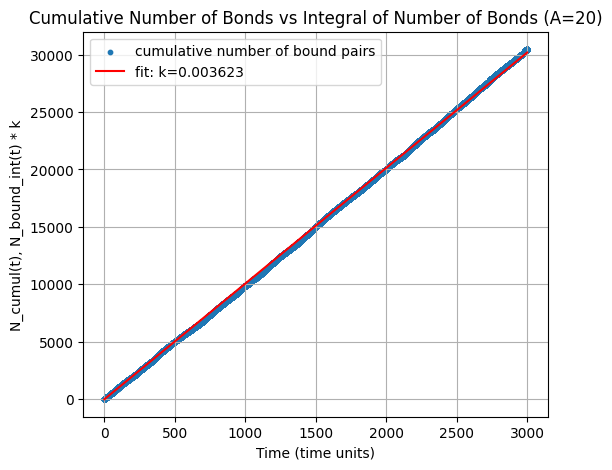

k = 0.0036232739232454334


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Fit N_cumul_list = k * N_bound_int + b (add bias term)
# Use the 'start' index defined earlier to select a tail portion
# Build arrays of times (in time units), N_bound values and N_cumul values
times = np.array(list(N_bound.keys())[start:], dtype=float)
n_b = np.array(list(N_bound.values())[start:], dtype=float)
n_c = np.array(list(N_cumul.values())[start:], dtype=float)

# Compute trapezoidal integral X(t) = \int_0^t N_bound dt (time units)
dt = np.diff(times)
segments = 0.5 * (n_b[1:] + n_b[:-1]) * dt
X = np.concatenate(([0.0], np.cumsum(segments)))

# Perform linear least-squares to get slope (k) and intercept (b): n_c = k * X + b
# A = np.vstack([X, np.ones_like(X)]).T
# k, b = np.linalg.lstsq(A, n_c, rcond=None)[0]   
k = X @ n_c / (X @ X) 

# Plot data and fit
plt.figure(figsize=(6,5))
plt.scatter(times, n_c, label='cumulative number of bound pairs', s=10)
# plt.plot(times, X, label="cumulative number of bound ")
plt.plot(times, k * X, label=f'fit: k={k:.4g}', color='red')
plt.title("Cumulative Number of Bonds vs Integral of Number of Bonds (A=20)")
plt.xlabel('Time (time units)')
plt.ylabel('N_cumul(t), N_bound_int(t) * k')
plt.grid(True)
plt.legend()
plt.show()

print(f"k = {k}")
